In [37]:
import pandas as pd
import numpy as np
df=pd.read_csv(r"C:\Users\Tufail Abbas\Downloads\properties_with_noise.csv")
df.head(5)

,propertyId,title,price,size,bedrooms,bathrooms,city,location,type,status,features
0,P001,Apartment in DHA Phase 6,249835,148,5,4,Lahore,DHA Phase 6,apartment,available,"['Servant Quarter', 'Balcony', 'Gym', 'Smart S..."
1,P002,Apartment in University Town,128928,62,4,4,Peshawar,University Town,apartment,available,"['Garage', 'Smart Security', 'Balcony', 'Garde..."
2,P003,Apartment in People's Colony,153295,86,4,5,Faisalabad,People's Colony,apartment,available,"['CCTV', 'Garage', 'Servant Quarter']"
3,P004,Villa in Bahria Town,291311,154,5,5,Lahore,Bahria Town,villa,available,"['Balcony', 'Elevator', 'CCTV', 'Swimming Pool']"
4,P005,Villa in Madina Town,300115,251,4,2,Faisalabad,Madina Town,villa,available,"['Garage', 'Balcony', 'Elevator', 'CCTV', 'Sma..."


In [2]:
df['location'].value_counts()

location
DHA                10
Madina Town         8
University Town     7
Cantt               7
Hayatabad           7
Bahria Enclave      7
Bahria Town         6
Gulshan-e-Iqbal     6
F-10                6
G-11                6
DHA Phase 6         5
Johar Town          5
Model Town          4
Canal Road          4
Clifton             4
People's Colony     3
Chaklala            3
Satellite Town      2
Name: count, dtype: int64

In [46]:
df['city'].value_counts()

city
Peshawar      19
Islamabad     19
Faisalabad    15
Lahore        14
Karachi       14
Multan        12
Rawalpindi     7
Name: count, dtype: int64

In [3]:
df.shape

(100, 11)

In [4]:
df.isnull().sum()

propertyId    0
title         0
price         0
size          0
bedrooms      0
bathrooms     0
city          0
location      0
type          0
status        0
features      0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   propertyId  100 non-null    str  
 1   title       100 non-null    str  
 2   price       100 non-null    int64
 3   size        100 non-null    int64
 4   bedrooms    100 non-null    int64
 5   bathrooms   100 non-null    int64
 6   city        100 non-null    str  
 7   location    100 non-null    str  
 8   type        100 non-null    str  
 9   status      100 non-null    str  
 10  features    100 non-null    str  
dtypes: int64(4), str(7)
memory usage: 8.7 KB


In [6]:
df.dtypes


propertyId      str
title           str
price         int64
size          int64
bedrooms      int64
bathrooms     int64
city            str
location        str
type            str
status          str
features        str
dtype: object

In [7]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
price,100.0,237899.38,60170.680642,105815.0,202454.25,228081.5,285640.50,379594.0
size,100.0,169.22,69.394725,62.0,109.00,158.0,239.25,290.0
bedrooms,100.0,4.04,1.413642,2.0,3.00,4.0,5.00,6.0
bathrooms,100.0,3.47,1.123262,2.0,2.00,4.0,4.00,5.0


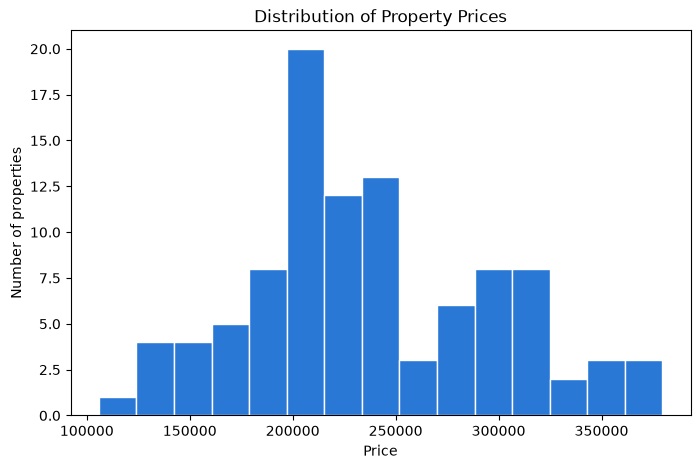

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=15, color='#2a78d6', edgecolor='white')
plt.xlabel("Price")
plt.ylabel("Number of properties")
plt.title("Distribution of Property Prices")
plt.show()

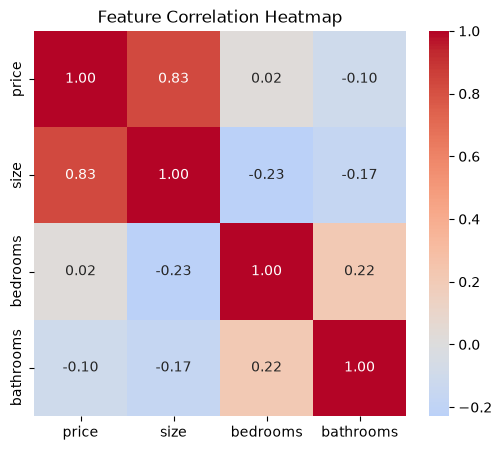

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['price','size','bedrooms','bathrooms']].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

In [10]:
X = df.drop("price", axis=1)
y = df["price"]

In [11]:
X=X.drop(['propertyId','title'],axis=1)

In [12]:
X.head(5)

,size,bedrooms,bathrooms,city,location,type,status,features
0,148,5,4,Lahore,DHA Phase 6,apartment,available,"['Servant Quarter', 'Balcony', 'Gym', 'Smart S..."
1,62,4,4,Peshawar,University Town,apartment,available,"['Garage', 'Smart Security', 'Balcony', 'Garde..."
2,86,4,5,Faisalabad,People's Colony,apartment,available,"['CCTV', 'Garage', 'Servant Quarter']"
3,154,5,5,Lahore,Bahria Town,villa,available,"['Balcony', 'Elevator', 'CCTV', 'Swimming Pool']"
4,251,4,2,Faisalabad,Madina Town,villa,available,"['Garage', 'Balcony', 'Elevator', 'CCTV', 'Sma..."


In [13]:
X = pd.get_dummies(
    X,
    columns=["city", "location", "type"],
    drop_first=True
)

In [14]:
X.head(5)

,size,bedrooms,bathrooms,status,features,city_Islamabad,city_Karachi,city_Lahore,city_Multan,city_Peshawar,...,location_Hayatabad,location_Johar Town,location_Madina Town,location_Model Town,location_People's Colony,location_Satellite Town,location_University Town,type_house,type_smart-home,type_villa
0,148,5,4,available,"['Servant Quarter', 'Balcony', 'Gym', 'Smart S...",False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,62,4,4,available,"['Garage', 'Smart Security', 'Balcony', 'Garde...",False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
2,86,4,5,available,"['CCTV', 'Garage', 'Servant Quarter']",False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,154,5,5,available,"['Balcony', 'Elevator', 'CCTV', 'Swimming Pool']",False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
4,251,4,2,available,"['Garage', 'Balcony', 'Elevator', 'CCTV', 'Sma...",False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True


In [15]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   size                      100 non-null    int64
 1   bedrooms                  100 non-null    int64
 2   bathrooms                 100 non-null    int64
 3   status                    100 non-null    str  
 4   features                  100 non-null    str  
 5   city_Islamabad            100 non-null    bool 
 6   city_Karachi              100 non-null    bool 
 7   city_Lahore               100 non-null    bool 
 8   city_Multan               100 non-null    bool 
 9   city_Peshawar             100 non-null    bool 
 10  city_Rawalpindi           100 non-null    bool 
 11  location_Bahria Town      100 non-null    bool 
 12  location_Canal Road       100 non-null    bool 
 13  location_Cantt            100 non-null    bool 
 14  location_Chaklala         100 non-null    bool 
 15  l

In [16]:
X["status"].unique()

<StringArray>
['available']
Length: 1, dtype: str

In [17]:
df["status"].value_counts()

status
available    100
Name: count, dtype: int64

In [18]:
X = X.drop("status", axis=1)

In [19]:
print(df["features"].iloc[0])
print(type(df["features"].iloc[0]))

['Servant Quarter', 'Balcony', 'Gym', 'Smart Security', 'Garage']
<class 'str'>


In [20]:
print(df["features"].head())

0    ['Servant Quarter', 'Balcony', 'Gym', 'Smart S...
1    ['Garage', 'Smart Security', 'Balcony', 'Garde...
2                ['CCTV', 'Garage', 'Servant Quarter']
3     ['Balcony', 'Elevator', 'CCTV', 'Swimming Pool']
4    ['Garage', 'Balcony', 'Elevator', 'CCTV', 'Sma...
Name: features, dtype: str


In [21]:
print(type(df["features"][0]))

<class 'str'>


In [22]:
import ast

df["features"] = df["features"].apply(ast.literal_eval)

In [23]:
print(type(df["features"][0]))

<class 'list'>


In [24]:
all_features = set()

for feature_list in df["features"]:
    for feature in feature_list:
        all_features.add(feature)

print(sorted(all_features))

['Balcony', 'CCTV', 'Elevator', 'Garage', 'Garden', 'Gym', 'Servant Quarter', 'Smart Security', 'Solar Panels', 'Swimming Pool']


In [25]:
for feature in all_features:
    X[feature] = X["features"].apply(
        lambda x: 1 if feature in x else 0
    )

In [26]:
X.head()

,size,bedrooms,bathrooms,features,city_Islamabad,city_Karachi,city_Lahore,city_Multan,city_Peshawar,city_Rawalpindi,...,Elevator,Garden,Gym,Smart Security,Servant Quarter,Solar Panels,Garage,Swimming Pool,CCTV,Balcony
0,148,5,4,"['Servant Quarter', 'Balcony', 'Gym', 'Smart S...",False,False,True,False,False,False,...,0,0,1,1,1,0,1,0,0,1
1,62,4,4,"['Garage', 'Smart Security', 'Balcony', 'Garde...",False,False,False,False,True,False,...,0,1,0,1,0,1,1,0,0,1
2,86,4,5,"['CCTV', 'Garage', 'Servant Quarter']",False,False,False,False,False,False,...,0,0,0,0,1,0,1,0,1,0
3,154,5,5,"['Balcony', 'Elevator', 'CCTV', 'Swimming Pool']",False,False,True,False,False,False,...,1,0,0,0,0,0,0,1,1,1
4,251,4,2,"['Garage', 'Balcony', 'Elevator', 'CCTV', 'Sma...",False,False,False,False,False,False,...,1,0,1,1,0,0,1,0,1,1


In [ ]:
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int) 

In [28]:
X.head()

,size,bedrooms,bathrooms,features,city_Islamabad,city_Karachi,city_Lahore,city_Multan,city_Peshawar,city_Rawalpindi,...,Elevator,Garden,Gym,Smart Security,Servant Quarter,Solar Panels,Garage,Swimming Pool,CCTV,Balcony
0,148,5,4,"['Servant Quarter', 'Balcony', 'Gym', 'Smart S...",0,0,1,0,0,0,...,0,0,1,1,1,0,1,0,0,1
1,62,4,4,"['Garage', 'Smart Security', 'Balcony', 'Garde...",0,0,0,0,1,0,...,0,1,0,1,0,1,1,0,0,1
2,86,4,5,"['CCTV', 'Garage', 'Servant Quarter']",0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,1,0
3,154,5,5,"['Balcony', 'Elevator', 'CCTV', 'Swimming Pool']",0,0,1,0,0,0,...,1,0,0,0,0,0,0,1,1,1
4,251,4,2,"['Garage', 'Balcony', 'Elevator', 'CCTV', 'Sma...",0,0,0,0,0,0,...,1,0,1,1,0,0,1,0,1,1


In [29]:
X = X.drop("features", axis=1)

In [30]:
X.head(5)

,size,bedrooms,bathrooms,city_Islamabad,city_Karachi,city_Lahore,city_Multan,city_Peshawar,city_Rawalpindi,location_Bahria Town,...,Elevator,Garden,Gym,Smart Security,Servant Quarter,Solar Panels,Garage,Swimming Pool,CCTV,Balcony
0,148,5,4,0,0,1,0,0,0,0,...,0,0,1,1,1,0,1,0,0,1
1,62,4,4,0,0,0,0,1,0,0,...,0,1,0,1,0,1,1,0,0,1
2,86,4,5,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,1,0
3,154,5,5,0,0,1,0,0,0,1,...,1,0,0,0,0,0,0,1,1,1
4,251,4,2,0,0,0,0,0,0,0,...,1,0,1,1,0,0,1,0,1,1


In [31]:
corr = df.corr(numeric_only=True)["price"].sort_values(ascending=False)
print(corr.head(10))

price        1.000000
size         0.827670
bedrooms     0.017589
bathrooms   -0.102864
Name: price, dtype: float64


In [32]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   size                      100 non-null    int64
 1   bedrooms                  100 non-null    int64
 2   bathrooms                 100 non-null    int64
 3   city_Islamabad            100 non-null    int64
 4   city_Karachi              100 non-null    int64
 5   city_Lahore               100 non-null    int64
 6   city_Multan               100 non-null    int64
 7   city_Peshawar             100 non-null    int64
 8   city_Rawalpindi           100 non-null    int64
 9   location_Bahria Town      100 non-null    int64
 10  location_Canal Road       100 non-null    int64
 11  location_Cantt            100 non-null    int64
 12  location_Chaklala         100 non-null    int64
 13  location_Clifton          100 non-null    int64
 14  location_DHA              100 non-null    int64
 15  l

In [33]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()
scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("R2 per fold:", scores)
print("Mean R2:", scores.mean())
print("Std R2:", scores.std())
 

R2 per fold: [0.9458559  0.80546391 0.80361699 0.90788835 0.92173782]
Mean R2: 0.8769125950871309
Std R2: 0.06033098342227058


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
eval_model = Ridge(alpha=1.5)
eval_model.fit(X_train, y_train)
y_pred = eval_model.predict(X_test)

print("Test R2:", r2_score(y_test, y_pred))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Error %:", (13918.44 / y_test.mean()) * 100)

Test R2: 0.9022679228975952
Test MAE: 13918.440760296764
Test RMSE: 15551.286224552932
Error %: 6.059060257186309


In [ ]:
print(df["price"].describe())

count       100.000000
mean     237899.380000
std       60170.680642
min      105815.000000
25%      202454.250000
50%      228081.500000
75%      285640.500000
max      379594.000000
Name: price, dtype: float64


In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(comparison.head(10))

    Actual      Predicted
83  235234  246901.624965
53  207747  182756.543377
70  220822  211181.131670
45  226034  221083.945254
44  208213  218889.434332
39  243005  264531.353439
22  152191  148277.344160
80  285459  301052.686485
10  219240  242090.746609
0   249835  234382.339818


In [ ]:
mae = 14224.842284699707

print("Average Price:", y_test.mean())
print("Error Percentage:", (mae / y_test.mean()) * 100)

Average Price: 229712.85
Error Percentage: 6.192445170002334


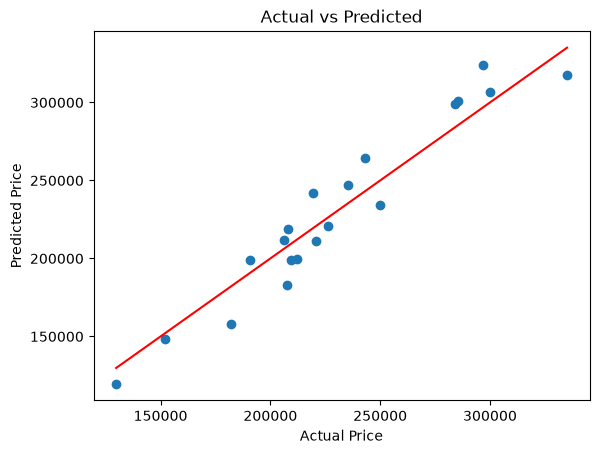

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

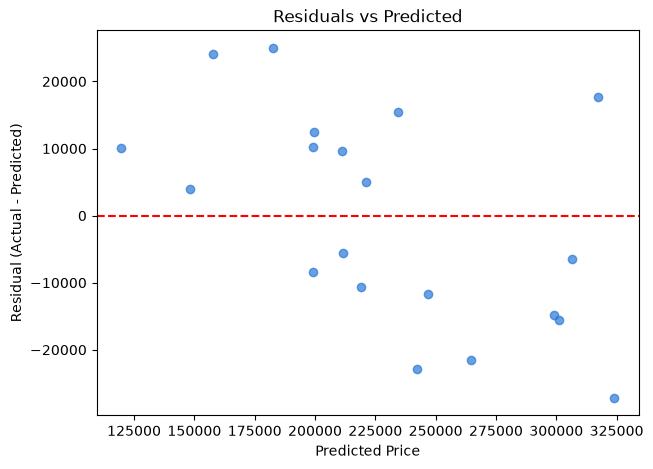

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.7, color='#2a78d6')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted")
plt.show()

In [35]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42)
scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("RF Mean R2:", scores.mean())

RF Mean R2: 0.7186819889749455


In [41]:
import joblib

final_model = Ridge(alpha=1.5)
final_model.fit(X, y)

joblib.dump(final_model, "price_model.pkl")
joblib.dump(X.columns.tolist(), "model_columns.pkl")
joblib.dump(sorted(all_features), "amenity_list.pkl")
joblib.dump(df["city"].unique().tolist(), "city_list.pkl")
joblib.dump(df["location"].unique().tolist(), "location_list.pkl")
joblib.dump(df["type"].unique().tolist(), "type_list.pkl")

['type_list.pkl']

In [44]:
import joblib

type_list = joblib.load("type_list.pkl")
print(type_list)

['apartment', 'villa', 'house', 'smart-home']


In [47]:
import joblib

for f in ["city_list.pkl", "location_list.pkl", "amenity_list.pkl", "model_columns.pkl", "status_list.pkl"]:
    print(f"\n--- {f} ---")
    print(joblib.load(f))


--- city_list.pkl ---
['Lahore', 'Peshawar', 'Faisalabad', 'Karachi', 'Multan', 'Islamabad', 'Rawalpindi']

--- location_list.pkl ---
['DHA Phase 6', 'University Town', "People's Colony", 'Bahria Town', 'Madina Town', 'Cantt', 'Hayatabad', 'Gulshan-e-Iqbal', 'Johar Town', 'DHA', 'Model Town', 'Canal Road', 'Clifton', 'Bahria Enclave', 'F-10', 'Chaklala', 'G-11', 'Satellite Town']

--- amenity_list.pkl ---
['Balcony', 'CCTV', 'Elevator', 'Garage', 'Garden', 'Gym', 'Servant Quarter', 'Smart Security', 'Solar Panels', 'Swimming Pool']

--- model_columns.pkl ---
['size', 'bedrooms', 'bathrooms', 'city_Islamabad', 'city_Karachi', 'city_Lahore', 'city_Multan', 'city_Peshawar', 'city_Rawalpindi', 'location_Bahria Town', 'location_Canal Road', 'location_Cantt', 'location_Chaklala', 'location_Clifton', 'location_DHA', 'location_DHA Phase 6', 'location_F-10', 'location_G-11', 'location_Gulshan-e-Iqbal', 'location_Hayatabad', 'location_Johar Town', 'location_Madina Town', 'location_Model Town', 

FileNotFoundError: [Errno 2] No such file or directory: 'status_list.pkl'